# ASL Recognition with CNNs

This notebook implements a Convolutional Neural Network (CNN) for recognizing American Sign Language (ASL) gestures. We will compare the performance of a Fully Connected Neural Network (FCNN) with that of a CNN on the ASL dataset.

For more information on the ASL alphabet, you can refer to this site: https://www.asl.gs/

In [1]:
import random

import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

False

In [3]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

data_base_path = "./data/" if IN_COLAB else "./data/"


### Load data

The data for the ASL dataset is stored in CSV files. It is already split into training, validation, and test sets. Each row in the CSV files contains pixel values for a 28x28 image (flattened into a single row) and a label indicating the ASL gesture.

The labels are integers from 0 to 23, corresponding to the letters A-Z (J and Z are excluded because they require movement).

The images are grayscale, so each pixel value ranges from 0 to 255.

In [4]:
train_df = pd.read_csv(data_base_path + "train.csv")
val_df = pd.read_csv(data_base_path + "val.csv")
test_df = pd.read_csv(data_base_path + "test.csv")

In [5]:
def label_to_letter(lbl):
    letter_code = ord('A') + int(lbl)
    return chr(letter_code) if letter_code < ord('J') else chr(letter_code + 1)

def show(img, lbl):
    i = img.reshape(28,28)
    plt.figure(figsize=(5,5))
    plt.title(label_to_letter(lbl), fontdict={'fontsize': 30})
    plt.axis('off')
    plt.imshow(i, cmap='gray')

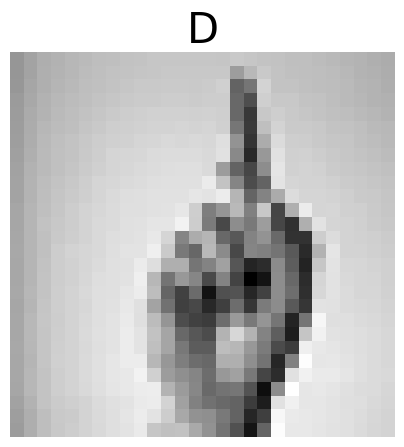

In [6]:
rnd_idx = random.choice(train_df.index)
image = train_df.iloc[rnd_idx].drop('label').values
label = train_df.iloc[rnd_idx]['label']
show(image, label)

## Preparing dataset

Let's start by creating the custom Dataset class for our ASL data. This class will take a DataFrame as input and will return the image and label for each sample. We will also normalize the pixel values to be between 0 and 1. The images will be reshaped as a 28x28 tensor with a single channel (grayscale).

In [7]:
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1

class AslDataset(Dataset):
    def __init__(self, base_df):
        x_df = base_df.copy()
        y_df = x_df.pop('label')
        x_df = x_df.values / 255
        x_df = x_df.reshape(-1, IMG_CHANNELS, IMG_WIDTH, IMG_HEIGHT)
        self.xs = torch.tensor(x_df).float().to(device)
        self.ys = torch.tensor(y_df).long().to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

In [8]:
train_data = AslDataset(train_df)
val_data = AslDataset(val_df)
test_data = AslDataset(test_df)

In [9]:
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

## Training functions

Now we can define our training functions. Since we will use accuracy to evaluate our model, we will create a function to calculate accuracy as well. 

In [10]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

Our train function performs the full training loop. For each epoch, it computes the training loss and accuracy, and then evaluates the model on the validation set. It returns the history of training and validation losses and accuracies for plotting later.

In [11]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

This test function will evaluate the model on the test set after training is complete. It will calculate the average loss and accuracy across the entire test set.

In [12]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc

## Training the models

### Baseline model - fully connected network

Before we implement the CNN, let's train a simple fully connected neural network (FCNN) as a baseline. This will help us understand the performance improvement that the CNN architecture provides for image data.

In [13]:
model_fcnn = nn.Sequential(
    nn.Flatten(),
    nn.Linear(IMG_HEIGHT * IMG_WIDTH, 512),
    nn.ReLU(),
    nn.Dropout(.3),

    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 24)
)

model_fcnn = model_fcnn.to(device)

In [14]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_fcnn.parameters())

fcnn_res = train(model_fcnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [01:20<00:00,  4.00s/epoch, train_acc=0.8605, train_loss=0.4008, val_acc=0.7284, val_loss=0.9872]


In [15]:
fcnn_test_loss, fcnn_test_acc = test(model_fcnn, test_loader, loss_function)

### CNN model

Now let's implement a simple CNN architecture. We will use three convolutional layers followed by max pooling, and then a couple of fully connected layers before the output layer.

In [16]:
model_cnn = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),  # 25 x 28 x 28
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 25 x 14 x 14

    nn.Conv2d(25, 50, 3, stride=1, padding=1),  # 50 x 14 x 14
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  # 50 x 7 x 7

    nn.Conv2d(50, 75, 3, stride=1, padding=1),  # 75 x 7 x 7
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, 24)
)

model_cnn = model_cnn.to(device)

In [17]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn.parameters())

cnn_res = train(model_cnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [05:26<00:00, 16.32s/epoch, train_acc=0.9985, train_loss=0.0058, val_acc=0.9626, val_loss=0.1442]


In [18]:
cnn_test_loss, cnn_test_acc = test(model_cnn, test_loader, loss_function)

## Reflection section

### Which model is better at classifying ASL images?

In [19]:
print(f"FCNN Test Loss: {fcnn_test_loss:.4f}, FCNN Test Accuracy: {fcnn_test_acc:.4f}")
print(f"CNN Test Loss: {cnn_test_loss:.4f}, CNN Test Accuracy: {cnn_test_acc:.4f}")

FCNN Test Loss: 0.9154, FCNN Test Accuracy: 0.7409
CNN Test Loss: 0.1433, CNN Test Accuracy: 0.9646


The best model at classifying ASL images is the **CNN model**. Its loss is 4x less, and it's accuracy is 20% higher.

### Which model was _faster_ to train?

The baseline model took `1m 22.5s` to train.
The CNN model took `5m 26.3s` to train.

The **baseline** model was **faster** to train.

### Plot and compare the learning curves of both models. What do you observe about their training and validation performance over epochs?

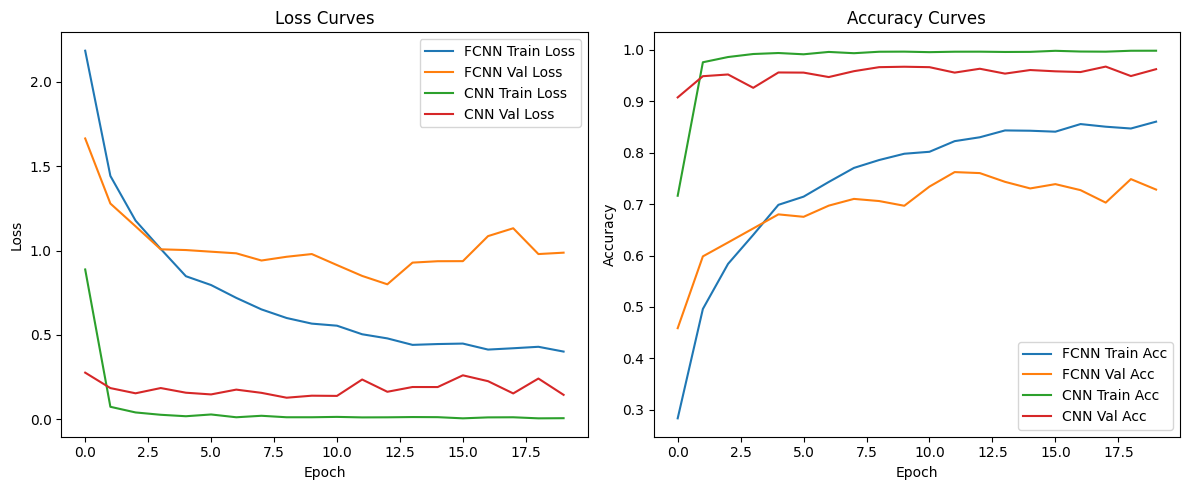

In [20]:
plt.figure(figsize=(12, 5))

# train loss
plt.subplot(1, 2, 1)
plt.plot(fcnn_res['train_loss'], label='FCNN Train Loss')
plt.plot(fcnn_res['val_loss'], label='FCNN Val Loss')
plt.plot(cnn_res['train_loss'], label='CNN Train Loss')
plt.plot(cnn_res['val_loss'], label='CNN Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# accuracy curves
plt.subplot(1, 2, 2)
plt.plot(fcnn_res['train_acc'], label='FCNN Train Acc')
plt.plot(fcnn_res['val_acc'], label='FCNN Val Acc')
plt.plot(cnn_res['train_acc'], label='CNN Train Acc')
plt.plot(cnn_res['val_acc'], label='CNN Val Acc')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# show
plt.tight_layout()
plt.show()

The difference in training and validation performance for both models for both metrics is evident. Across the epochs, the models had a similar behavior in terms of performance improvement:
- In their loss curve, both models had an initial dip. As expected, because the model has zero understanding of the phenomenon.
- After their initial dip, the training loss for CNN plateaued, while the baseline model continuously dropped. However, it never reached the near-perfect loss value of the CNN model.
- In validation, both models fluctuated between improvement and degradation, as expected. This is because they're working on data they weren't trained on. Their performance was the same.
- Because their behavior was nearly identical because of the nature of the models and the phenomenon, CNN outshined because it had a way lower baseline.

In terms of accuracy:
- These behaviors translate almost perfectly. Training for CNN takes a huge leap and plateaus. Meanwhile, training for the baseline model continuously improves but never reaches the performance of the CNN model.
- When it comes to validation accuracy, the behavior is, once again, the same. They fluctuate between improvement and degradation, because this is the validation set. However, once again, CNN outshines because it is naturally better.

### How many trainable parameters does each model have?

>Remember that each convolutional layer has $K \times (C_{in} \times k_h \times k_w + 1)$ parameters, where $K$ is the number of filters, $C_{in}$ is the number of input channels, $k_h$ and $k_w$ are the kernel height and width, and the +1 accounts for the bias term.

>Each fully connected layer has $N_{in} \times N_{out} + N_{out}$ parameters, where $N_{in}$ is the number of input features and $N_{out}$ is the number of output features.

The baseline, using the function given has the following amount of parameters. Given, $N_{in} \times N_{out} + N_{out}$:

| Layer | Math | Trainable Parameters |
| --- | --- | --- |
| $nn.Linear(784 \rightarrow 512)$ | $784 \cdot 512 + 512$ | $401,920$ |
| $nn.Linear(512 \rightarrow 512)$ | $512 \cdot 512 + 512$ | $262,656$ |
| $nn.Linear(512 \rightarrow 24)$ | $512 \cdot 24 + 24$ | $12,312$ |
| **Total** | | $676,888$ |

And the CNN model, using $K \times (C_{in} \times k_h \times k_w + 1)$. Given $C_{in} = 1$:

| Layer | Math | Trainable Parameters |
| --- | --- | --- |
| $nn.Conv2d(C_{in} \rightarrow 25, 3 \times 3)$ | $25 \cdot (1 \cdot 3 \cdot 3 + 1)$ | $250$ |
| $nn.Conv2d(25 \rightarrow 50, 3 \times 3)$ | $50 \cdot (25 \cdot 3 \cdot 3 + 1)$ | $11,300$ |
| $nn.Conv2d(50 \rightarrow 75, 3 \times 3)$ | $75 \cdot (50 \cdot 3 \cdot 3 + 1)$ | $33,825$ |
| $nn.Linear(675 \rightarrow 512)$ | $674 \cdot 512 + 512$ | $346,112$ |
| $nn.Linear(512 \rightarrow 24)$ | $512 \cdot 24 + 24$ | $12,312$ |
| **Total** | | $403,799$ |

**The baseline model has $676,888$ trainable parameters.**

**The CNN model has $403,799$ trainable parameters.**

We can verify this like so: (taken from PyTorch documentation)

In [21]:
baseline_params = sum(p.numel() for p in model_fcnn.parameters() if p.requires_grad)
cnn_params = sum(p.numel() for p in model_cnn.parameters() if p.requires_grad)

print(f"Baseline FCNN Parameters: {baseline_params}")
print(f"CNN Parameters: {cnn_params}")

Baseline FCNN Parameters: 676888
CNN Parameters: 403799


### How do the models compare in terms of overfitting? Why do you think that is the case?

The baseline model has more overrfitting than the CNN model. This is because the gap between the training, validation and test accuracy is more noticeable on the baseline model than it is on our CNN model.

| Model | Train Accuracy | Validation Accuracy | Test Accuracy | Train - Val |
| --- | --- | --- |--- | --- |
| Baseline | 86.05% | 72.84% | 74.09% | 13.21% |
| CNN | 99.85% | 96.26% | 96.46% | 3.59% |

As you can see, the difference between training and validation accuracy in the baseline model is greater (by almost 4x) than our CNN model. This means that the model performed VASTLY better on the training set than on validation and it wasn't able to learn patterns as well to predict on (new) other data.

 I think this is the case because the filter that passes through the entire image on the CNN model learns local patterns, which means that it can detect patterns on *any* group of pixels on the canvas. Conversely, the baseline model (FCNN) doesn't do this, meaning it processes the entire image at once, and assumes that certain patterns or behaviors will be at the same location. This explains why the accuracy is much lower on the baseline model, and why it had a much lower performance on validation/test than it did on training, mostly because the patterns it learned were *isolated* to the training set. 

### Final conclusions and remarks

All in all, I think this is a great opportunity to explain the importance of understanding what each model is for and what makes CNN perform best on image data.

- A CNN uses filters (kernels) that help it learn local patterns in a given space. This means that it is best at isolating behaviors that would otherwise be generalized on its FCNN counterpart. This is also why its training was 5x longer. 

- Particularily, CNN performed much better than the FCNN model. The FCNN model had more overfitting because it wasn't able to isolate the patterns found and apply them to the validation and test set. For example, lines at one location wouldn't be treated the same at another location (on the validation/test set).

- Its great localized pattern recognition also explains its learning curve's behavior. There's a big leap at the start, indicating that the model worked perfectly, but it then plateaus. This plateau happens because the nature of the problem and the data we're working with allows CNN to perform in optimal conditions. These conditions range from fixed-size images and very sharp edges.

-  The model could benefit from early-stopping to avoid the much higher training time while preserving its performance.